## Customer Churn prediction Using Machine learning

### Business problem
In subscription based business the bigger problem isn't acquring new customer, The big problem is retaining the available customer
The goal of this project is to develop a machine learning model that predicts whether a customer is likely to leave the company, allowing businesses to proactively target retention efforts.

#### Project Objectives

1. Explore and understand the customer data
2. Clean and prepare the dataset
3. Perform exploratory data analysis (EDA)
4. Engineer features for machine learning
5. Train multiple classification models
6. Evaluate model performance
7. Identify the most important factors influencing customer churn
8. Provide business recommendations based on the results


In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv("Telco Customer Churn.csv")

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.shape

(7043, 21)

In [5]:
print(f"Rows:, {df.shape[0]}")

print(f"Columns:, {df.shape[1]}")


Rows:, 7043
Columns:, 21


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [7]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [8]:
pd.isna(df).sum()


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [9]:
df.duplicated().sum()

0

## Change totalCharges to Numeric
The TotalCharges column is stored as an object even though it represents a numeric value. This usually means the column contains blank or non-numeric values that need to be corrected.

In [10]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [11]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'],errors = "coerce")

In [12]:
df['TotalCharges'].isna().sum()

11

After Converting TotalCharges to numeric datatype, 11 missing values appeared and since it is a small number we drop them

In [13]:
df.dropna(inplace = True)

In [14]:
df = df.drop("customerID", axis=1)


In [15]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [16]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441
std,0.368844,24.545260,30.085974,2266.771362
min,0.000000,1.000000,18.250000,18.800000
25%,0.000000,9.000000,35.587500,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.862500,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


## Exploratory data Analysis (EDA)
we will expplore questions such as:
1. How many Customers Churned?
2. Which contact type has the highest churn?
3. Does tenure affect churn?
4. Does monthly Charges affect churn?
5. Are senior citizens more likely to churn?
6. Does Internet services affect churn


In [17]:
#How many Customers Churned?
df["Churn"].value_counts()

Churn
No     5163
Yes    1869
Name: count, dtype: int64

Text(0, 0.5, 'Number of customers')

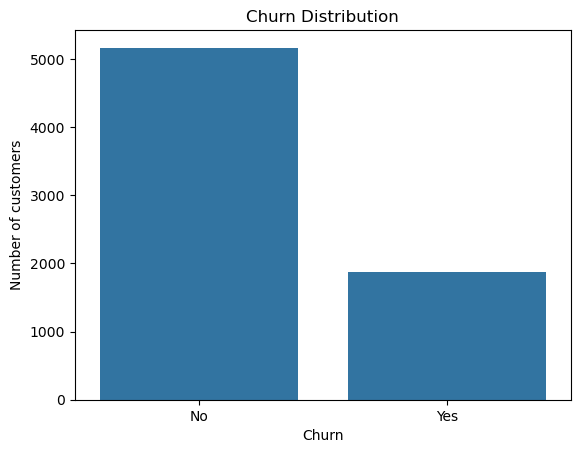

In [18]:
sns.countplot(df,x="Churn")
plt.title("Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of customers")

Text(0, 0.5, 'Number of customers')

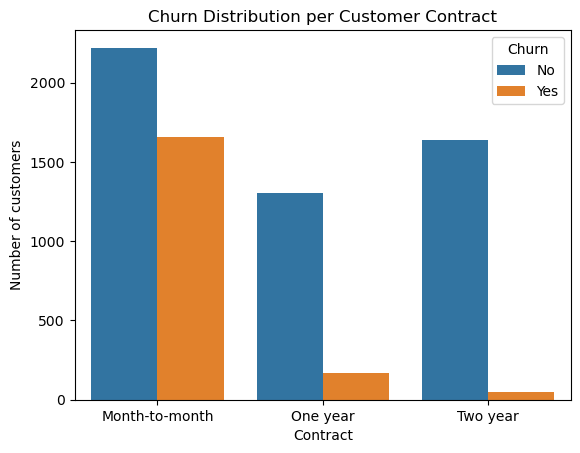

In [19]:
#Which contact type has the highest churn?
sns.countplot(df,x="Contract", hue="Churn")
plt.title("Churn Distribution per Customer Contract")
plt.xlabel("Contract")
plt.ylabel("Number of customers")

Text(0, 0.5, 'Number of customers')

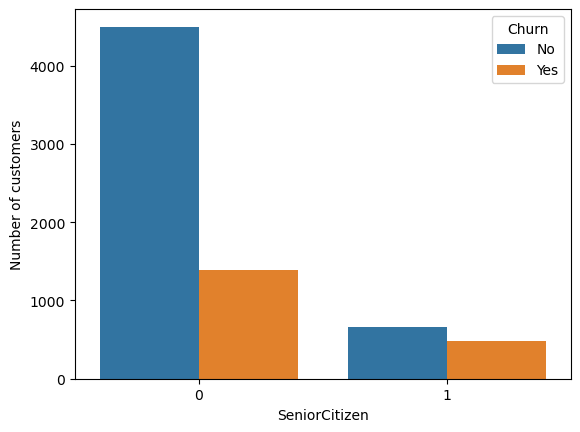

In [20]:
sns.countplot(df,x="SeniorCitizen", hue="Churn")

plt.ylabel("Number of customers")

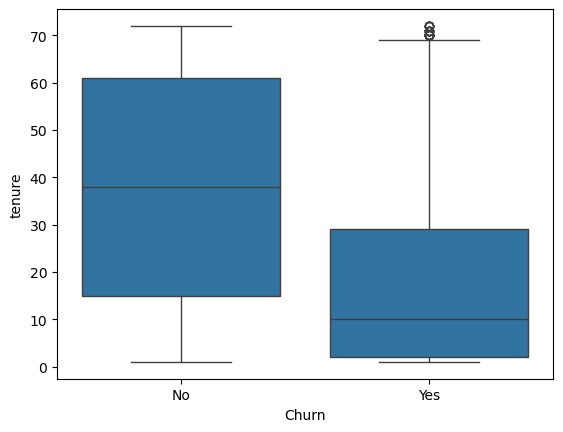

In [21]:
#Does tenure affect churn?
sns.boxplot(df,y="tenure",x="Churn")
plt.show()

Customer Tenure shows how long the customer has stayed with the company. from the above boxplot, it shows that customers who have stayed long with the company are less likely to churn

Text(0.5, 1.0, 'Monthly Charges Distribution')

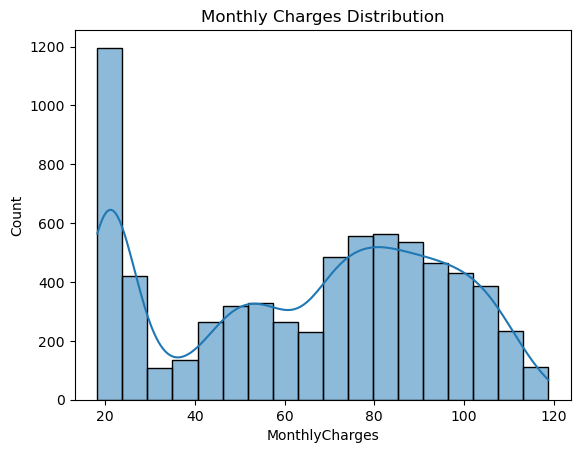

In [22]:
#Monthly charges Distribution
sns.histplot(df,x="MonthlyCharges",kde=True,stat='count')
plt.title("Monthly Charges Distribution")

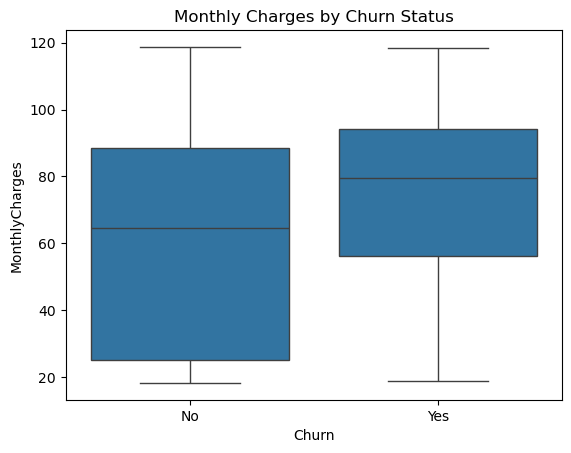

In [23]:
sns.boxplot(df,y="MonthlyCharges",x="Churn")
plt.title ("Monthly Charges by Churn Status")
plt.show()

Clearly the Graph shows that customers with High monthly charges are high likely to churn compared to those with  low monthly charges

In [24]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

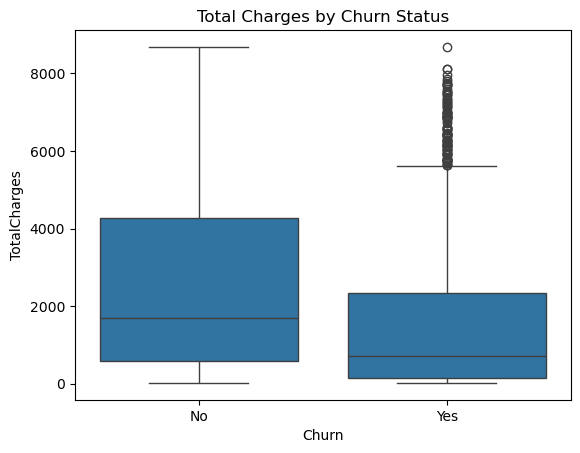

In [25]:
sns.boxplot(df,y="TotalCharges",x="Churn")
plt.title ("Total Charges by Churn Status")
plt.show()

Text(0, 0.5, 'Number of customers')

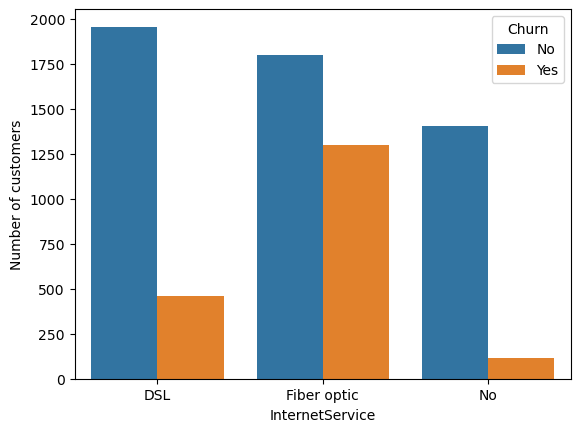

In [26]:
#Does Internet services affect churn
sns.countplot(df,x="InternetService", hue="Churn")

plt.ylabel("Number of customers")

## Corelation Between Numetic variables

In [27]:
df.dtypes

gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object

<Axes: >

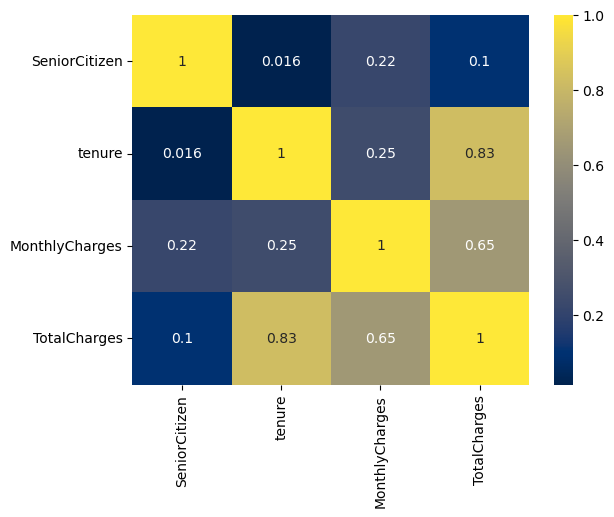

In [28]:
numeric_df=df.select_dtypes(["int64","float64"])
sns.heatmap(numeric_df.corr(),annot=True,cmap="cividis")

### Cross Tabs To See the percentage of customers within Groups

In [29]:
pd.crosstab(df["Contract"],df["Churn"], normalize="index")*100

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.722826,11.277174
Two year,97.151335,2.848665


The type of contract makes a great deal of difference when it comes to churn rate. The churn rate of those customers on a month-to-month contract was the highest at 42.71%. On the other hand, the churn rate for customers who were under contracts of one year and two years stood at 11.28% and 2.85% respectively. It can, therefore, be concluded that customers with longer contracts have significantly less probability of leaving the organization.

In [30]:
pd.crosstab(df["SeniorCitizen"],df["Churn"], normalize="index")*100

Churn,No,Yes
SeniorCitizen,,
0,76.349745,23.650255
1,58.318739,41.681261


Seniors' status seems to be a key determinant of customer churn. From the results of the study, one can see that 41.68% of seniors were churning while only 23.65% of non-seniors were doing so. It means that senior citizens are prone to churn more often than others. This fact can be due to their special requirements or interests in the product they use.

In [31]:
pd.crosstab(df["InternetService"],df["Churn"], normalize="index")*100

Churn,No,Yes
InternetService,,
DSL,81.001656,18.998344
Fiber optic,58.107235,41.892765
No,92.565789,7.434211


## Feature Engineering
Machine learning models require numerical input. This section converts categorical variables into numerical values, prepares the target variable, and creates the training and testing datasets.

In [32]:
#convert the target Variable to numeric
df["Churn"]=df["Churn"].map({"No":0,"Yes":1})

In [33]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [34]:
df["Churn"].value_counts()

Churn
0    5163
1    1869
Name: count, dtype: int64

In [35]:
categorical=df.select_dtypes(include="object").columns
print(categorical)

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')


In [36]:
#creating New Variable
#np.where(condition,value_if_true,value_if_false)
df["AvgMonthlySpend"] = np.where(df["tenure"] == 0,0,df["TotalCharges"]/df["tenure"])

In [37]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,AvgMonthlySpend
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,29.850000
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,No,No,No,One year,No,Mailed check,56.95,1889.50,0,55.573529
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,54.075000
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0,40.905556
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,75.825000


In [38]:
df_encoded=df.copy()

## Encode Categorical Features
Machine learning algorithms cannot directly process text values. All remaining categorical features are converted into numerical representations using one-hot encoding.

In [39]:
from sklearn.preprocessing import LabelEncoder

In [40]:
binary_cols = [
    "gender",
    "Partner",
    "Dependents",
    "PhoneService",
    "PaperlessBilling",
    "Churn"
]

le = LabelEncoder()

for col in binary_cols:
    df_encoded[col] = le.fit_transform(df[col])

In [41]:
multi_cat_cols = [
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaymentMethod"
]

df_encoded = pd.get_dummies(
    df_encoded,
    columns=multi_cat_cols,
    drop_first=True,
    dtype=int
)

In [42]:
df_encoded.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,0,...,0,0,0,0,0,0,0,0,1,0
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,0,0,0,0,0,1,0,0,0,1
2,1,0,0,0,2,1,1,53.85,108.15,1,...,0,0,0,0,0,0,0,0,0,1
3,1,0,0,0,45,0,0,42.30,1840.75,0,...,1,0,0,0,0,1,0,0,0,0
4,0,0,0,0,2,1,1,70.70,151.65,1,...,0,0,0,0,0,0,0,0,1,0


## Tran-Test-Split

We first separate the dataset into Features (X) and Target variable (y)

In [44]:
X=df_encoded.drop("Churn", axis=1)
y=df_encoded["Churn"]

In [46]:
from sklearn.model_selection import train_test_split

In [48]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,stratify=y)

In [58]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, f1_score, roc_auc_score, accuracy_score

In [65]:
Lr= LogisticRegression(max_iter=1000)

In [66]:
Lr.fit(X_train,y_train)

/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [67]:
y_pred = Lr.predict(X_test)

In [68]:
log_prob = Lr.predict_proba(X_test)[:, 1]

In [69]:
log_prob

array([0.01850383, 0.57666795, 0.00474549, ..., 0.1381089 , 0.02503401,
       0.00452007])

In [70]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, log_prob))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.8038379530916845
ROC-AUC: 0.8365813191421072

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



In [71]:
print("\nConfussion Matrix:")
print(confusion_matrix(y_test, y_pred))


Confussion Matrix:
[[917 116]
 [160 214]]


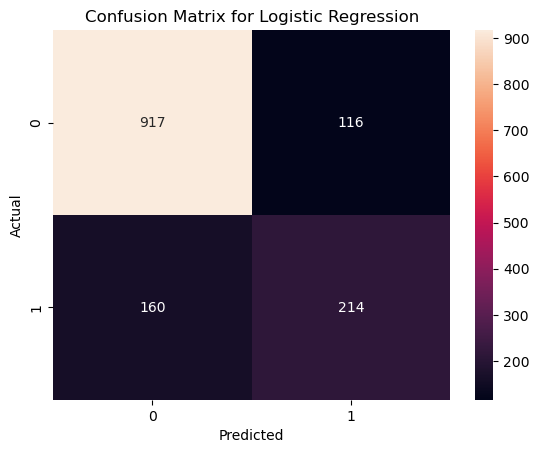

In [86]:
sns.heatmap(confusion_matrix(y_test, y_pred),annot=True,fmt="d")
plt.title("Confusion Matrix for Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Random Forest Classifier

In [72]:
from sklearn.ensemble import RandomForestClassifier

In [73]:
RF= RandomForestClassifier()

In [74]:
RF.fit(X_train,y_train)

RandomForestClassifier()

In [77]:
rf_pred = RF.predict(X_test)
rf_prob = RF.predict_proba(X_test)

In [79]:
print("Accuracy:", accuracy_score(y_test, rf_pred))
# Extract probabilities for the positive class (column 1) from the 2D probability array
print("ROC-AUC:", roc_auc_score(y_test, rf_prob[:, 1]))
print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

Accuracy: 0.7938877043354655
ROC-AUC: 0.8214509424292465

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1033
           1       0.64      0.51      0.57       374

    accuracy                           0.79      1407
   macro avg       0.74      0.70      0.72      1407
weighted avg       0.78      0.79      0.79      1407



In [80]:
print("\nConfussion Matrix:")
print(confusion_matrix(y_test, rf_pred))


Confussion Matrix:
[[927 106]
 [184 190]]


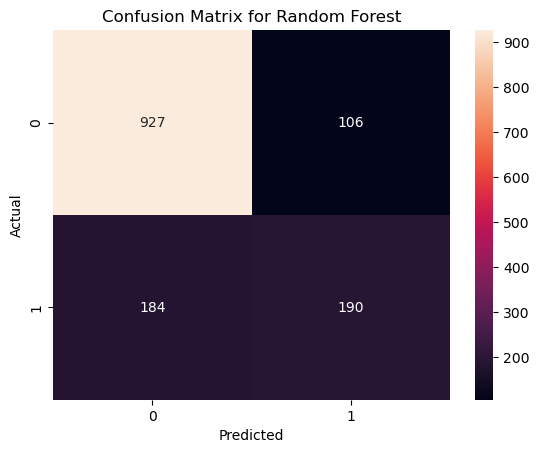

In [87]:
sns.heatmap(confusion_matrix(y_test, rf_pred),annot=True,fmt="d")
plt.title("Confusion Matrix for Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

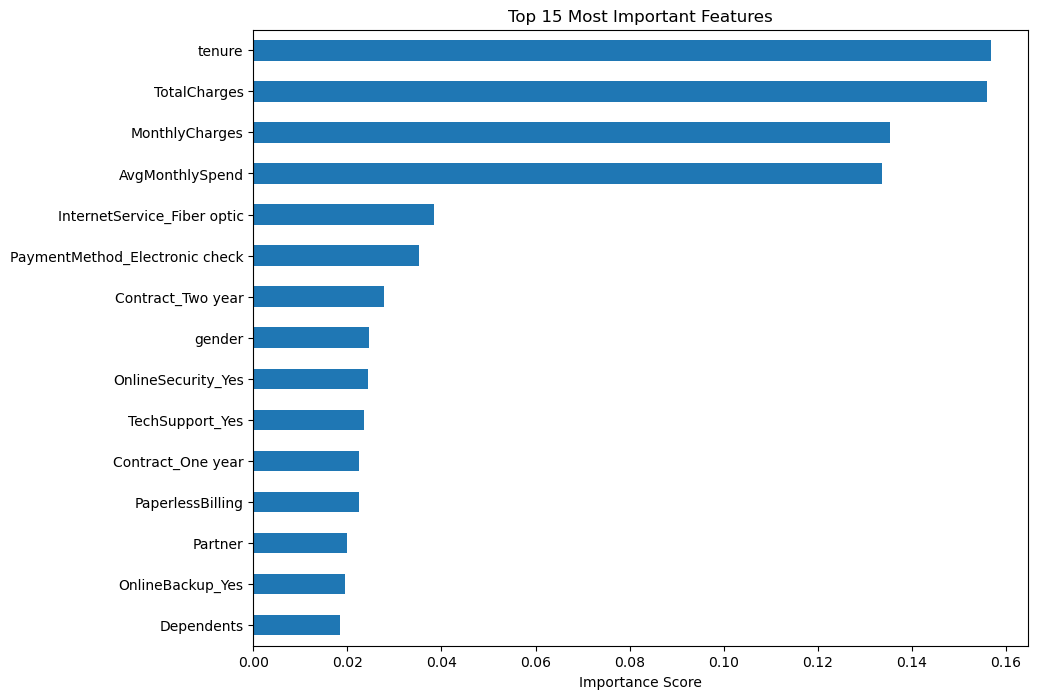

In [90]:
feature_importance = pd.Series(
    RF.feature_importances_,  
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(10,8))

feature_importance.head(15).plot(kind="barh")

plt.title("Top 15 Most Important Features")
plt.xlabel("Importance Score")

plt.gca().invert_yaxis()

plt.show()

In [95]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, rf_pred)
    ],
    "ROC-AUC": [
        # Remove the [:, 1] indexing since the arrays are already 1-dimensional
        roc_auc_score(y_test, log_prob),  # Use the 1D probability array directly
        roc_auc_score(y_test, rf_prob[:, 1])    # Use the 1D probability array directly
    ]
})

comparison.sort_values("ROC-AUC", ascending=False)

,Model,Accuracy,ROC-AUC
0,Logistic Regression,0.803838,0.836581
1,Random Forest,0.793888,0.821451


## Conclusion
The classification algorithms used to predict customer churn include logistic regression and random forest. It was found that Logistic Regression performs better than Random Forest in terms of all the main evaluation metrics. Specifically, Logistic Regression is able to achieve a high accuracy of 80.38%, while Random Forest can reach only 79.39%. Also, logistic regression reaches a higher ROC-AUC score of 0.8366, which means its better discriminative capacity with respect to distinguishing between customers that churn and those that stay. In addition, Logistic Regression has achieved better results for precision (65%), recall (57%), and F1-score (61%). Thus, based on the above observations, the choice of Logistic Regression is optimal because it offers great performance, while being relatively easy to interpret and compute.